#**Labubu**

---



Nama Anggota :

                  Baihaqi Nur Muhammad 24083010111
                  Muhammad Jazuli 24083010093
                  Daffa Muhammad Khrisadi 24083010062
                  Made Surya Darmawan Rijasa 24083010119

---



              


## 0. Persiapan Lingkungan & Pemuatan Data

Mengimpor pustaka dan memuat dataset. Kolom `tanggal` langsung diparse sebagai tipe *datetime* agar bisa digunakan untuk analisis temporal (Velocity & Variability).

In [ ]:
# Pustaka dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid", palette="deep")

# Muat data — parse kolom tanggal sebagai datetime
df = pd.read_csv("dps_bmkg_merged.csv", parse_dates=["tanggal"])
df = df.sort_values("tanggal").reset_index(drop=True)

print(f"Dimensi dataset : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Rentang tanggal : {df['tanggal'].min().date()}  s/d  {df['tanggal'].max().date()}")
df.head()

Dimensi dataset : 457 baris x 21 kolom
Rentang tanggal : 2025-03-01  s/d  2026-05-31


,tanggal,total_flight,early,ontime,delay,cancelled,operated,pct_ontime,pct_delay,avg_delay_menit,...,suhu_max,suhu_avg,kelembapan,curah_hujan,rr_imputed,kategori_hujan,penyinaran_jam,angin_max_ms,angin_avg_ms,arah_angin
0,2025-03-01,170,36,80,44,10,160,72.5,27.5,27.9,...,32.3,28.0,81.0,11.4,False,Ringan,8.0,4.0,2.0,E
1,2025-03-02,43,13,24,5,1,42,88.1,11.9,28.6,...,32.1,28.7,81.0,1.2,False,Sangat Ringan,8.0,4.0,2.0,E
2,2025-03-03,150,35,74,37,4,146,74.7,25.3,31.5,...,32.2,28.6,77.0,0.0,False,Tidak Hujan,8.0,4.0,2.0,E
3,2025-03-04,160,39,90,28,3,157,82.2,17.8,26.4,...,31.3,28.5,79.0,1.7,False,Sangat Ringan,8.0,4.0,2.0,E
4,2025-03-05,171,28,109,33,1,170,80.6,19.4,26.7,...,32.0,28.8,81.0,0.0,False,Tidak Hujan,8.0,5.0,3.0,E


In [ ]:
# Sekilas struktur & tipe data tiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   tanggal          457 non-null    datetime64[us]
 1   total_flight     457 non-null    int64         
 2   early            457 non-null    int64         
 3   ontime           457 non-null    int64         
 4   delay            457 non-null    int64         
 5   cancelled        457 non-null    int64         
 6   operated         457 non-null    int64         
 7   pct_ontime       457 non-null    float64       
 8   pct_delay        457 non-null    float64       
 9   avg_delay_menit  457 non-null    float64       
 10  suhu_min         457 non-null    float64       
 11  suhu_max         457 non-null    float64       
 12  suhu_avg         457 non-null    float64       
 13  kelembapan       457 non-null    float64       
 14  curah_hujan      457 non-null    float64       
 15  

# 1. Analisis 8V Big Data

Kerangka **8V** dipakai untuk mengkarakterisasi sebuah dataset dari berbagai dimensi. Di bawah ini tiap "V" dijelaskan **dan dibuktikan langsung dengan kode** pada dataset penerbangan–cuaca ini.

## 1.1 Volume — *Berapa banyak data?*

**Volume** merujuk pada besarnya kuantitas data. Dataset ini tergolong **skala kecil–menengah** (bukan "big" dalam arti petabyte), namun mewakili sebuah *agregasi harian*: tiap baris adalah ringkasan dari ratusan penerbangan dan beberapa pengamatan cuaca dalam satu hari. Artinya volume "mentah" di baliknya jauh lebih besar daripada 457 baris yang terlihat.

In [ ]:
n_baris, n_kolom = df.shape
total_sel = n_baris * n_kolom
mem_kb = df.memory_usage(deep=True).sum() / 1024
total_penerbangan = int(df["total_flight"].sum())

print(f"Jumlah baris (hari)        : {n_baris:,}")
print(f"Jumlah kolom (fitur)       : {n_kolom}")
print(f"Total sel data             : {total_sel:,}")
print(f"Penggunaan memori          : {mem_kb:,.1f} KB")
print(f"Total penerbangan teragregasi : {total_penerbangan:,} penerbangan")
print(f"Rata-rata penerbangan/hari    : {df['total_flight'].mean():.0f}")

Jumlah baris (hari)        : 457
Jumlah kolom (fitur)       : 21
Total sel data             : 9,597
Penggunaan memori          : 113.7 KB
Total penerbangan teragregasi : 92,617 penerbangan
Rata-rata penerbangan/hari    : 203


## 1.2 Velocity — *Seberapa cepat data dihasilkan?*

**Velocity** adalah kecepatan datangnya data. Dataset ini bersifat **batch harian** (*daily granularity*): satu record baru muncul setiap hari. Kita verifikasi bahwa rentang waktunya **kontinu tanpa bolong** — syarat penting agar analisis deret waktu valid.

In [ ]:
selisih = df["tanggal"].diff().dt.days.dropna()
print("Distribusi selisih hari antar baris:")
print(selisih.value_counts())
print(f"\nDuplikat tanggal           : {df['tanggal'].duplicated().sum()}")
print(f"Total rentang hari kalender : {(df['tanggal'].max() - df['tanggal'].min()).days + 1}")
print(f"Jumlah record tersedia      : {len(df)}")

if (selisih == 1).all() and df['tanggal'].duplicated().sum() == 0:
    print("\n>> Velocity: data harian KONTINU (1 hari = 1 record), tidak ada gap/duplikat.")
else:
    print("\n>> Perhatian: ada gap atau duplikat pada deret waktu.")

Distribusi selisih hari antar baris:
tanggal
1.0    456
Name: count, dtype: int64

Duplikat tanggal           : 0
Total rentang hari kalender : 457
Jumlah record tersedia      : 457

>> Velocity: data harian KONTINU (1 hari = 1 record), tidak ada gap/duplikat.


## 1.3 Variety — *Seberapa beragam jenis & sumber data?*

**Variety** menyoroti keragaman tipe dan asal data. Dataset ini **memadukan dua domain berbeda**:

| Domain | Sumber | Contoh kolom |
|---|---|---|
| Operasional penerbangan | Maskapai / bandara DPS | `total_flight`, `delay`, `cancelled`, `pct_ontime` |
| Meteorologi | BMKG | `suhu_avg`, `curah_hujan`, `kelembapan`, `arah_angin` |

Dari sisi *tipe data* juga beragam: numerik kontinu, numerik diskret (hitungan), kategorikal nominal, kategorikal ordinal, boolean, dan temporal.

In [ ]:
# Klasifikasi kolom berdasarkan peran semantik
kelompok = {
    "Operasional (numerik)": ["total_flight","early","ontime","delay","cancelled","operated",
                               "pct_ontime","pct_delay","avg_delay_menit"],
    "Cuaca (numerik)"      : ["suhu_min","suhu_max","suhu_avg","kelembapan","curah_hujan",
                               "penyinaran_jam","angin_max_ms","angin_avg_ms"],
    "Kategorikal"          : ["kategori_hujan","arah_angin"],
    "Boolean (flag)"       : ["rr_imputed"],
    "Temporal"             : ["tanggal"],
}
for k, v in kelompok.items():
    print(f"{k:24s}: {len(v)} kolom -> {v}")

print("\nRingkasan tipe data pandas:")
print(df.dtypes.value_counts())

Operasional (numerik)   : 9 kolom -> ['total_flight', 'early', 'ontime', 'delay', 'cancelled', 'operated', 'pct_ontime', 'pct_delay', 'avg_delay_menit']
Cuaca (numerik)         : 8 kolom -> ['suhu_min', 'suhu_max', 'suhu_avg', 'kelembapan', 'curah_hujan', 'penyinaran_jam', 'angin_max_ms', 'angin_avg_ms']
Kategorikal             : 2 kolom -> ['kategori_hujan', 'arah_angin']
Boolean (flag)          : 1 kolom -> ['rr_imputed']
Temporal                : 1 kolom -> ['tanggal']

Ringkasan tipe data pandas:
float64           11
int64              6
str                2
datetime64[us]     1
bool               1
Name: count, dtype: int64


## 1.4 Veracity — *Seberapa dapat dipercaya data ini?*

**Veracity** menilai kualitas, akurasi, dan keterpercayaan data: nilai hilang, anomali, dan jejak manipulasi. Dataset ini relatif bersih, namun ada **dua catatan kejujuran** penting:

- Kolom `rr_imputed` adalah *flag* yang menandai bahwa **curah hujan hari tersebut hasil imputasi** (bukan pengukuran asli) — sebuah praktik dokumentasi kualitas yang baik.
- Kolom `arah_angin` memiliki nilai ganjil `E;SE` yang perlu dibersihkan.

In [ ]:
print("=== Nilai hilang per kolom ===")
miss = df.isna().sum()
print(miss[miss > 0] if miss.sum() else "Tidak ada missing value sama sekali.")

print(f"\n=== Jejak imputasi (rr_imputed) ===")
print(df["rr_imputed"].value_counts())
print(f"{df['rr_imputed'].mean()*100:.1f}% hari curah hujannya hasil imputasi, bukan pengukuran asli.")

print("\n=== Anomali kategori arah_angin ===")
print(df["arah_angin"].value_counts())

print("\n=== Deteksi outlier (metode IQR) pada kolom kunci ===")
for col in ["total_flight","curah_hujan","avg_delay_menit","angin_max_ms"]:
    q1, q3 = df[col].quantile([.25,.75]); iqr = q3 - q1
    out = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    print(f"  {col:18s}: {out:3d} outlier ({out/len(df)*100:.1f}%)")

=== Nilai hilang per kolom ===
Tidak ada missing value sama sekali.

=== Jejak imputasi (rr_imputed) ===
rr_imputed
False    427
True      30
Name: count, dtype: int64
6.6% hari curah hujannya hasil imputasi, bukan pengukuran asli.

=== Anomali kategori arah_angin ===
arah_angin
SE      168
W       139
E       120
NW        9
SW        9
S         9
NE        2
E;SE      1
Name: count, dtype: int64

=== Deteksi outlier (metode IQR) pada kolom kunci ===
  total_flight      :  20 outlier (4.4%)
  curah_hujan       :  73 outlier (16.0%)
  avg_delay_menit   :   3 outlier (0.7%)
  angin_max_ms      :  78 outlier (17.1%)


## 1.5 Value — *Nilai/manfaat apa yang bisa diambil?*

**Value** adalah inti dari semua "V": data hanya berguna jika menghasilkan wawasan yang bisa ditindaklanjuti. Potensi nilai dataset ini:

- **Operasional bandara** — mengantisipasi hari-hari rawan delay untuk penjadwalan kru & gate.
- **Komunikasi penumpang** — peringatan dini keterlambatan berbasis prakiraan cuaca.
- **Riset akademik** — menguji hipotesis "cuaca buruk → delay meningkat".

Sebagai bukti awal nilai, kita lihat seberapa kuat sinyal cuaca terhadap keterlambatan.

In [ ]:
fitur_uji = ["curah_hujan","kelembapan","suhu_avg","suhu_max","penyinaran_jam",
             "angin_max_ms","angin_avg_ms","total_flight"]
korelasi = df[fitur_uji + ["pct_delay"]].corr()["pct_delay"].drop("pct_delay")
print("Korelasi (Pearson) tiap fitur terhadap pct_delay:")
print(korelasi.sort_values(key=abs, ascending=False).round(3))

print("\nInterpretasi awal:")
print("- Sinyal CUACA terhadap delay tergolong LEMAH (|r| < 0.4).")
print("- Beban operasional (total_flight) & suhu adalah indikator paling informatif.")
print(">> Nilai utama: model prediksi tetap mungkin, tetapi cuaca saja TIDAK cukup.")

Korelasi (Pearson) tiap fitur terhadap pct_delay:
total_flight      0.390
suhu_max         -0.373
suhu_avg         -0.306
curah_hujan       0.127
angin_avg_ms      0.051
penyinaran_jam   -0.048
kelembapan        0.038
angin_max_ms      0.016
Name: pct_delay, dtype: float64

Interpretasi awal:
- Sinyal CUACA terhadap delay tergolong LEMAH (|r| < 0.4).
- Beban operasional (total_flight) & suhu adalah indikator paling informatif.
>> Nilai utama: model prediksi tetap mungkin, tetapi cuaca saja TIDAK cukup.


## 1.6 Variability — *Seberapa fluktuatif data sepanjang waktu?*

**Variability** berbeda dari Variety. Variability menyoroti *inkonsistensi & fluktuasi nilai dari waktu ke waktu* — misalnya lonjakan musiman, perubahan ragam (*variance*), dan kemiringan distribusi (*skewness*). Curah hujan adalah contoh klasik variabilitas tinggi (banyak nol, sesekali ekstrem).

In [ ]:
from scipy.stats import skew

print("=== Koefisien variasi (CV = std/mean) — makin tinggi makin fluktuatif ===")
for col in ["curah_hujan","cancelled","total_flight","pct_delay","suhu_avg"]:
    cv = df[col].std() / df[col].mean() if df[col].mean() else np.nan
    print(f"  {col:16s}: CV = {cv:6.2f} | skewness = {skew(df[col]):6.2f}")

# Variabilitas bulanan pada pct_delay
df["bulan"] = df["tanggal"].dt.to_period("M").astype(str)
var_bulan = df.groupby("bulan")["pct_delay"].agg(["mean","std"]).round(2)
print("\n=== Variabilitas pct_delay antar bulan (rata-rata & simpangan) ===")
print(var_bulan)

=== Koefisien variasi (CV = std/mean) — makin tinggi makin fluktuatif ===
  curah_hujan     : CV =   2.40 | skewness =   4.53
  cancelled       : CV =   1.42 | skewness =   1.81
  total_flight    : CV =   0.12 | skewness =   3.97
  pct_delay       : CV =   0.18 | skewness =  -0.63
  suhu_avg        : CV =   0.03 | skewness =  -0.58

=== Variabilitas pct_delay antar bulan (rata-rata & simpangan) ===
          mean    std
bulan                
2025-03  35.06  12.86
2025-04  46.39   6.54
2025-05  46.66   4.91
2025-06  53.78   7.53
2025-07  55.43   4.31
2025-08  53.34   4.69
2025-09  47.89   5.81
2025-10  48.68   7.01
2025-11  45.87   4.38
2025-12  47.47   8.51
2026-01  45.50   7.34
2026-02  47.28   7.26
2026-03  44.29   9.23
2026-04  44.71   5.57
2026-05  41.38   7.27


## 1.7 Validity — *Apakah data masuk akal & konsisten secara logis?*

**Validity** memeriksa apakah nilai mematuhi *aturan bisnis & batasan logis*, terlepas dari ada/tidaknya missing value. Kita uji beberapa **aturan integritas**:

1. `suhu_min ≤ suhu_avg ≤ suhu_max`
2. `pct_ontime + pct_delay ≈ 100`
3. `early + ontime + delay ≈ operated` (komponen menyusun total operasi)
4. `operated ≤ total_flight` (yang dioperasikan tak melebihi total terjadwal)
5. Persentase berada di rentang [0, 100], kelembapan ≤ 100

In [ ]:
cek = {}
cek["suhu_min <= avg <= max"]      = ((df.suhu_min<=df.suhu_avg)&(df.suhu_avg<=df.suhu_max)).mean()
cek["pct_ontime+pct_delay ~ 100"]  = (np.abs(df.pct_ontime+df.pct_delay-100)<=1.0).mean()
cek["early+ontime+delay ~ operated"]= (np.abs(df.early+df.ontime+df.delay-df.operated)<=2).mean()
cek["operated <= total_flight"]    = (df.operated<=df.total_flight).mean()
cek["kelembapan dalam 0-100"]      = df.kelembapan.between(0,100).mean()
cek["pct dalam 0-100"]             = (df.pct_ontime.between(0,100)&df.pct_delay.between(0,100)).mean()

print("=== Hasil uji aturan validitas (proporsi baris yang LOLOS) ===")
for aturan, p in cek.items():
    status = "OK " if p > 0.99 else "CEK"
    print(f"  [{status}] {aturan:32s}: {p*100:6.2f}% lolos")

valid_kat = {"Tidak Hujan","Sangat Ringan","Ringan","Sedang","Lebat","Sangat Lebat","Ekstrem"}
print(f"\nKategori hujan tak terduga: {set(df.kategori_hujan.unique()) - valid_kat or 'tidak ada'}")

=== Hasil uji aturan validitas (proporsi baris yang LOLOS) ===
  [OK ] suhu_min <= avg <= max          :  99.78% lolos
  [OK ] pct_ontime+pct_delay ~ 100      : 100.00% lolos
  [OK ] early+ontime+delay ~ operated   : 100.00% lolos
  [OK ] operated <= total_flight        : 100.00% lolos
  [OK ] kelembapan dalam 0-100          : 100.00% lolos
  [OK ] pct dalam 0-100                 : 100.00% lolos

Kategori hujan tak terduga: tidak ada


## 1.8 Visualization — *Bagaimana data disajikan agar mudah dipahami?*

**Visualization** adalah "V" yang menjembatani data dengan manusia. Visual yang tepat mengubah angka mentah jadi wawasan instan. Berikut panel ringkas empat sudut pandang dataset; eksplorasi lebih dalam dilakukan di bagian **EDA**.

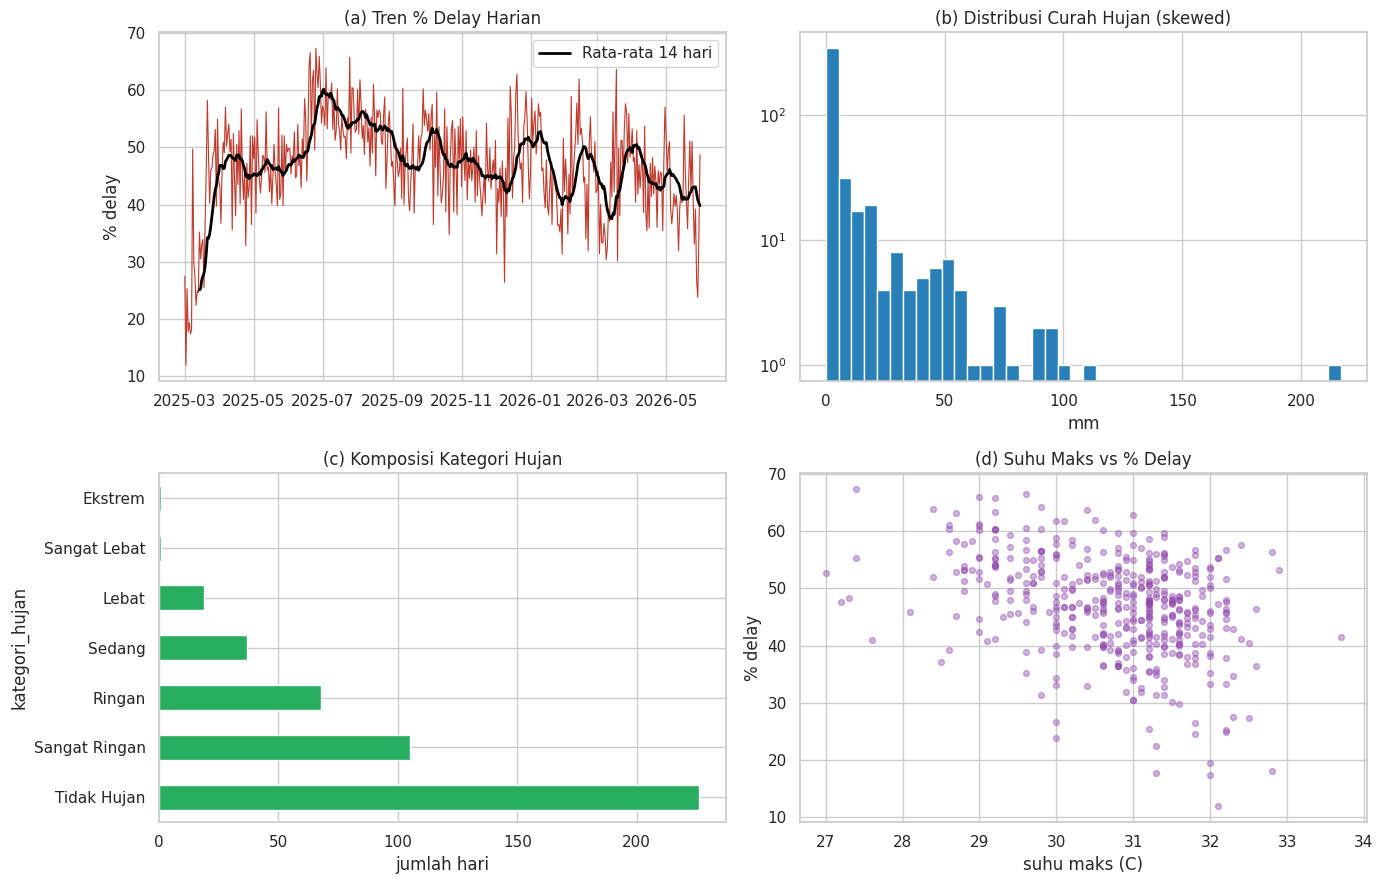

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# (a) Tren keterlambatan harian
ax[0,0].plot(df.tanggal, df.pct_delay, lw=0.8, color="#c0392b")
ax[0,0].plot(df.tanggal, df.pct_delay.rolling(14).mean(), lw=2, color="black", label="Rata-rata 14 hari")
ax[0,0].set_title("(a) Tren % Delay Harian"); ax[0,0].set_ylabel("% delay"); ax[0,0].legend()

# (b) Distribusi curah hujan (variabilitas ekstrem)
ax[0,1].hist(df.curah_hujan, bins=40, color="#2980b9", edgecolor="white")
ax[0,1].set_title("(b) Distribusi Curah Hujan (skewed)"); ax[0,1].set_xlabel("mm"); ax[0,1].set_yscale("log")

# (c) Komposisi kategori hujan
df.kategori_hujan.value_counts().plot(kind="barh", ax=ax[1,0], color="#27ae60")
ax[1,0].set_title("(c) Komposisi Kategori Hujan"); ax[1,0].set_xlabel("jumlah hari")

# (d) Hubungan suhu maksimum vs delay
ax[1,1].scatter(df.suhu_max, df.pct_delay, alpha=0.4, color="#8e44ad", s=18)
ax[1,1].set_title("(d) Suhu Maks vs % Delay"); ax[1,1].set_xlabel("suhu maks (C)"); ax[1,1].set_ylabel("% delay")

plt.tight_layout(); plt.show()

### Ringkasan Analisis 8V

| V | Temuan Utama pada Dataset Ini |
|---|---|
| **Volume** | 457 hari × 21 kolom; meringkas ±92 ribu penerbangan. |
| **Velocity** | Batch harian, kontinu tanpa gap/duplikat. |
| **Variety** | 2 domain (operasional + meteorologi); 5 tipe data berbeda. |
| **Veracity** | Bersih dari missing; 30 hari hujan hasil imputasi; ada anomali `E;SE`. |
| **Value** | Berpotensi untuk prediksi delay, tapi sinyal cuaca lemah. |
| **Variability** | Curah hujan sangat fluktuatif & *skewed*; delay bervariasi antar bulan. |
| **Validity** | Lolos seluruh aturan logis (suhu, persentase, komposisi). |
| **Visualization** | Panel multi-sudut memetakan tren, distribusi, & relasi. |


# 2. Exploratory Data Analysis (EDA)

Pada bagian ini kita menggali lebih dalam: ringkasan statistik, distribusi target, hubungan antar variabel, pola musiman, dan efek cuaca terhadap keterlambatan.

## 2.1 Ringkasan Statistik Deskriptif

In [ ]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
tanggal,457,2025-10-15 00:00:00,2025-03-01 00:00:00,2025-06-23 00:00:00,2025-10-15 00:00:00,2026-02-06 00:00:00,2026-05-31 00:00:00,NaN
total_flight,457.0,202.66302,43.0,196.0,204.0,210.0,517.0,23.453206
early,457.0,16.684902,3.0,11.0,16.0,21.0,46.0,7.397935
ontime,457.0,88.332604,24.0,79.0,88.0,96.0,221.0,14.738618
delay,457.0,94.407002,5.0,81.0,96.0,109.0,259.0,22.951718
cancelled,457.0,3.238512,0.0,0.0,1.0,4.0,28.0,4.609535
operated,457.0,199.424508,42.0,192.0,200.0,208.0,517.0,24.212493
pct_ontime,457.0,53.094967,32.7,47.1,52.5,58.3,88.1,8.62122
pct_delay,457.0,46.905033,11.9,41.7,47.5,52.9,67.3,8.62122
avg_delay_menit,457.0,30.978556,23.9,29.7,31.0,32.4,37.5,1.958847


## 2.2 Distribusi Variabel Target

Kita fokus pada `pct_delay` (persentase penerbangan terlambat per hari) sebagai indikator utama keterlambatan.

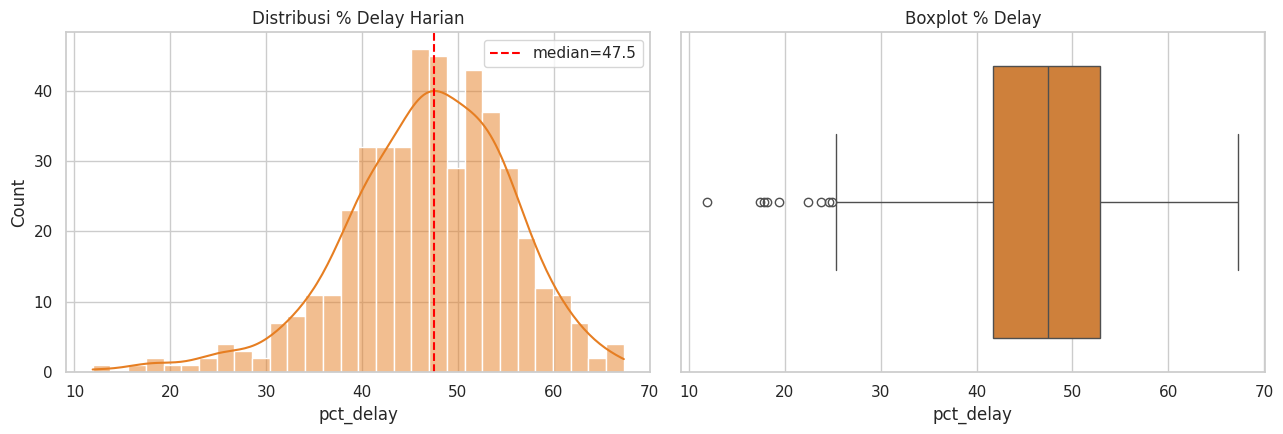

Mean   : 46.91%
Median : 47.50%
Std    : 8.62


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df.pct_delay, kde=True, bins=30, ax=ax[0], color="#e67e22")
ax[0].axvline(df.pct_delay.median(), color="red", ls="--", label=f"median={df.pct_delay.median():.1f}")
ax[0].set_title("Distribusi % Delay Harian"); ax[0].legend()

sns.boxplot(x=df.pct_delay, ax=ax[1], color="#e67e22")
ax[1].set_title("Boxplot % Delay")
plt.tight_layout(); plt.show()

print(f"Mean   : {df.pct_delay.mean():.2f}%")
print(f"Median : {df.pct_delay.median():.2f}%")
print(f"Std    : {df.pct_delay.std():.2f}")

## 2.3 Matriks Korelasi Antar Variabel Numerik

Heatmap membantu melihat fitur mana yang saling berkaitan kuat — sekaligus mendeteksi *multikolinearitas* (mis. `suhu_min/avg/max`).

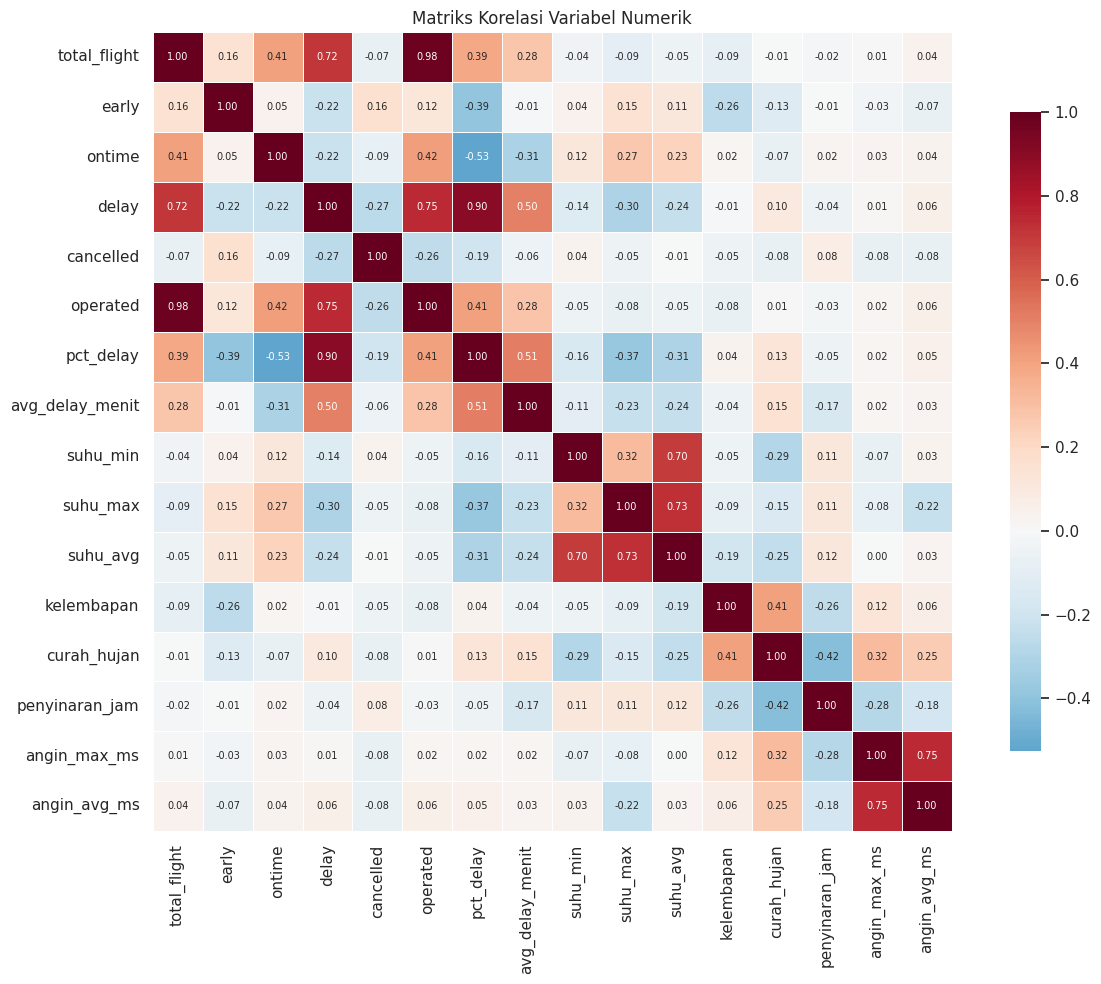

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(["pct_ontime"])  # pct_ontime = 100 - pct_delay (redundan)
plt.figure(figsize=(13, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink":.8}, annot_kws={"size":7})
plt.title("Matriks Korelasi Variabel Numerik")
plt.tight_layout(); plt.show()

## 2.4 Keterlambatan menurut Kategori Hujan

Apakah hari yang lebih hujan benar-benar lebih sering delay? Kategori `Sangat Lebat` & `Ekstrem` digabung karena sampelnya sangat sedikit (masing-masing 1 hari).

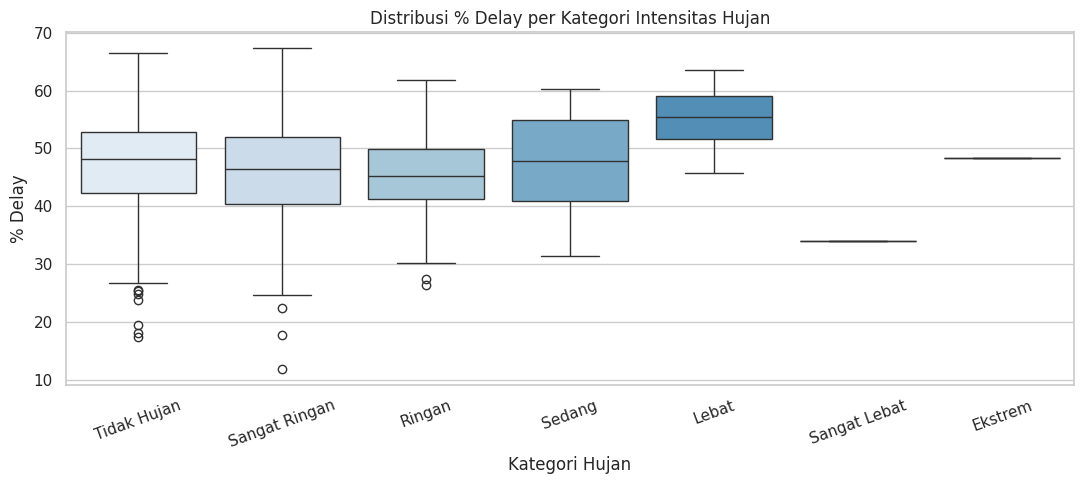

                count   mean  median
kategori_hujan                      
Tidak Hujan       226  47.25   48.20
Sangat Ringan     105  45.44   46.40
Ringan             68  45.52   45.25
Sedang             37  47.56   47.90
Lebat              19  55.14   55.40
Sangat Lebat        1  34.00   34.00
Ekstrem             1  48.30   48.30


In [ ]:
urutan = ["Tidak Hujan","Sangat Ringan","Ringan","Sedang","Lebat","Sangat Lebat","Ekstrem"]
plt.figure(figsize=(11,5))
sns.boxplot(data=df, x="kategori_hujan", y="pct_delay", order=urutan, palette="Blues")
plt.title("Distribusi % Delay per Kategori Intensitas Hujan")
plt.xticks(rotation=20); plt.xlabel("Kategori Hujan"); plt.ylabel("% Delay")
plt.tight_layout(); plt.show()

print(df.groupby("kategori_hujan")["pct_delay"].agg(["count","mean","median"]).reindex(urutan).round(2))

## 2.5 Pola Musiman (Agregasi Bulanan)

Membandingkan rata-rata bulanan delay, curah hujan, dan beban penerbangan untuk melihat keterkaitan musiman.

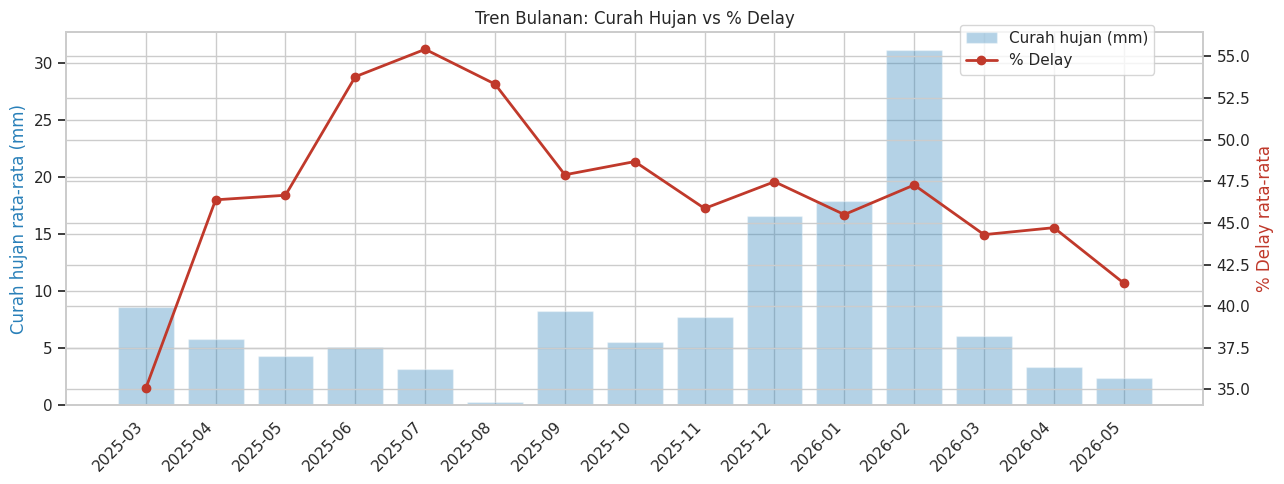

In [ ]:
bln = df.groupby("bulan").agg(pct_delay=("pct_delay","mean"),
                               curah_hujan=("curah_hujan","mean"),
                               total_flight=("total_flight","mean")).reset_index()

fig, ax1 = plt.subplots(figsize=(13,5))
ax1.bar(bln.bulan, bln.curah_hujan, alpha=0.35, color="#2980b9", label="Curah hujan (mm)")
ax1.set_ylabel("Curah hujan rata-rata (mm)", color="#2980b9")
ax2 = ax1.twinx()
ax2.plot(bln.bulan, bln.pct_delay, color="#c0392b", marker="o", lw=2, label="% Delay")
ax2.set_ylabel("% Delay rata-rata", color="#c0392b")
ax1.set_title("Tren Bulanan: Curah Hujan vs % Delay")
ax1.set_xticklabels(bln.bulan, rotation=45, ha="right")
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.95))
plt.tight_layout(); plt.show()

## 2.6 Efek Hari dalam Seminggu

Beban dan pola penerbangan sering bergantung pada hari (akhir pekan vs hari kerja).

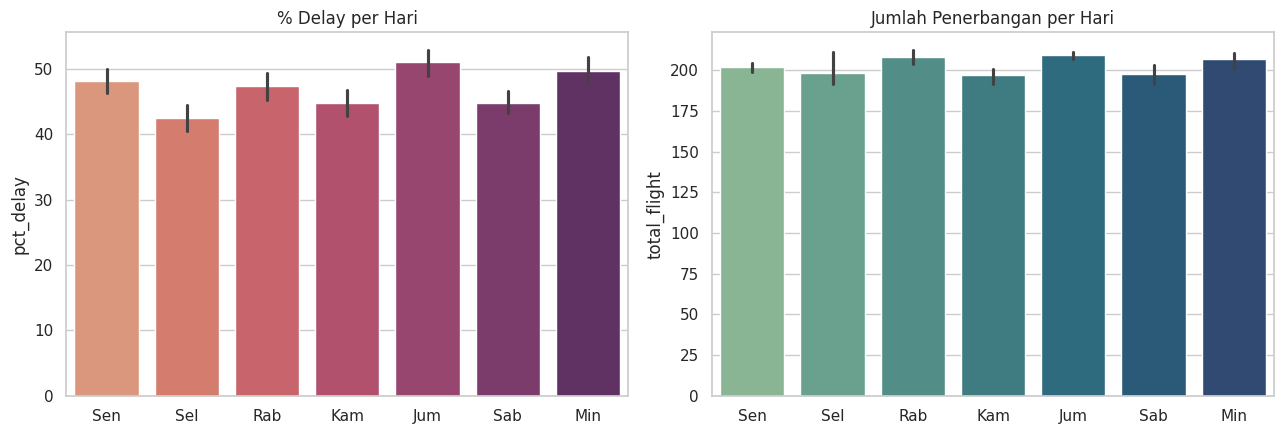

In [ ]:
hari_urut = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hari_id   = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
df["nama_hari"] = df["tanggal"].dt.day_name()

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sns.barplot(data=df, x="nama_hari", y="pct_delay", order=hari_urut, ax=ax[0], palette="flare")
ax[0].set_title("% Delay per Hari"); ax[0].set_xticklabels(hari_id); ax[0].set_xlabel("")
sns.barplot(data=df, x="nama_hari", y="total_flight", order=hari_urut, ax=ax[1], palette="crest")
ax[1].set_title("Jumlah Penerbangan per Hari"); ax[1].set_xticklabels(hari_id); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

## 2.7 Analisis Univariat Tiap Fitur Cuaca

Sebelum melihat hubungan antar variabel, kita periksa **distribusi masing-masing fitur cuaca secara individual**. Ini mengungkap bentuk sebaran (normal, miring, bimodal), rentang nilai dominan, dan kehadiran nilai ekstrem pada tiap variabel.

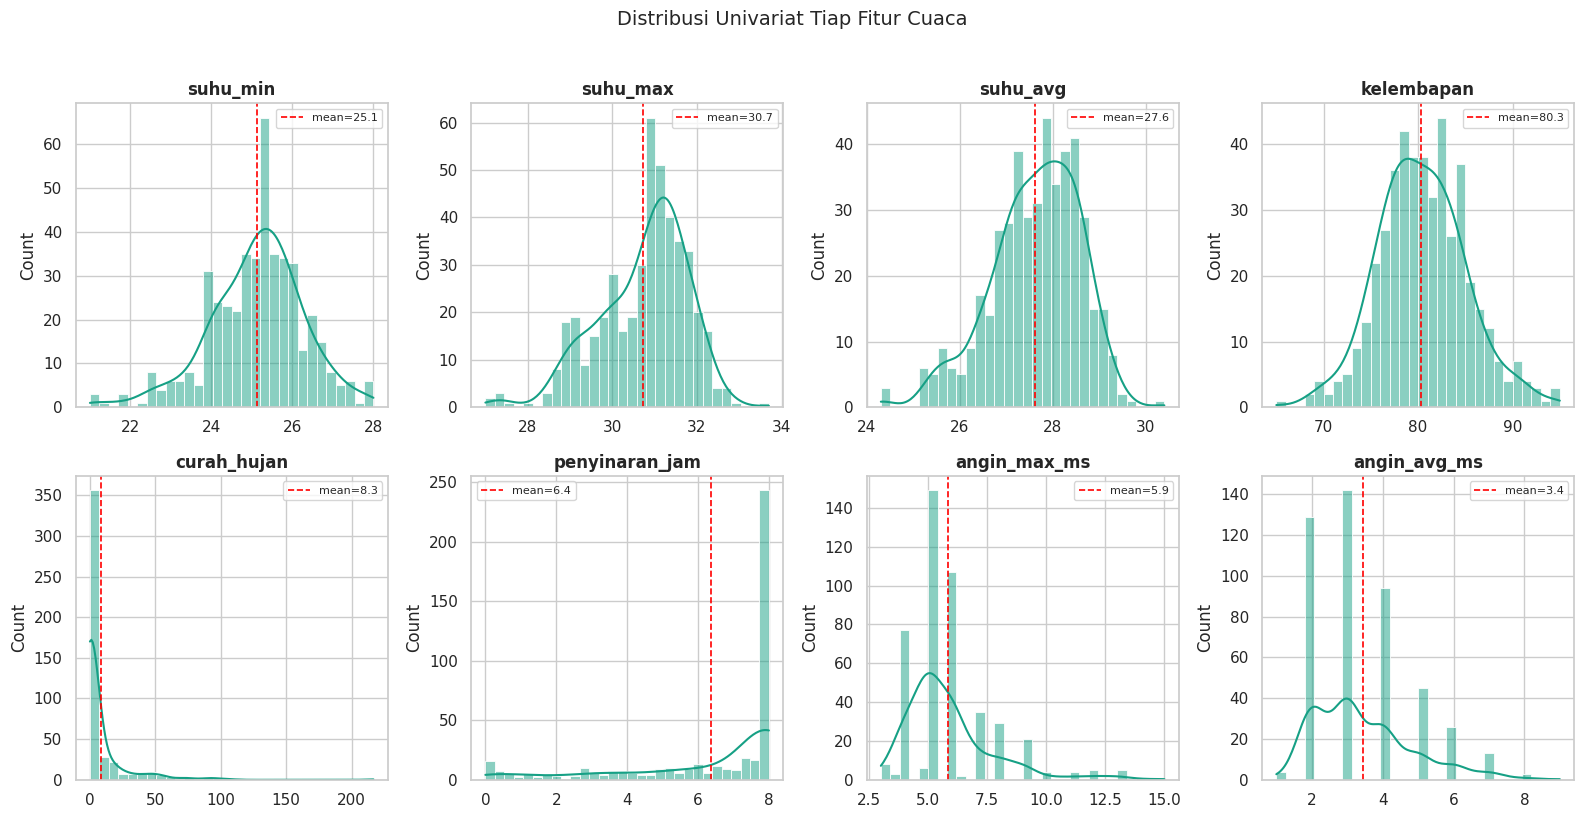

Skewness tiap fitur (0=simetris, >0=ekor kanan, <0=ekor kiri):
  suhu_min        :  -0.48  (simetris)
  suhu_max        :  -0.67  (miring kiri)
  suhu_avg        :  -0.58  (miring kiri)
  kelembapan      :   0.19  (simetris)
  curah_hujan     :   4.53  (miring kanan)
  penyinaran_jam  :  -1.39  (miring kiri)
  angin_max_ms    :   1.74  (miring kanan)
  angin_avg_ms    :   1.00  (miring kanan)


In [ ]:
fitur_cuaca = ["suhu_min","suhu_max","suhu_avg","kelembapan","curah_hujan",
               "penyinaran_jam","angin_max_ms","angin_avg_ms"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), fitur_cuaca):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="#16a085")
    ax.axvline(df[col].mean(), color="red", ls="--", lw=1.2, label=f"mean={df[col].mean():.1f}")
    ax.set_title(col, fontweight="bold"); ax.set_xlabel(""); ax.legend(fontsize=8)
plt.suptitle("Distribusi Univariat Tiap Fitur Cuaca", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Ringkasan bentuk distribusi via skewness
from scipy.stats import skew
print("Skewness tiap fitur (0=simetris, >0=ekor kanan, <0=ekor kiri):")
for col in fitur_cuaca:
    s = skew(df[col])
    bentuk = "simetris" if abs(s)<0.5 else ("miring kanan" if s>0 else "miring kiri")
    print(f"  {col:16s}: {s:6.2f}  ({bentuk})")

## 2.8 Scatter Plot Fitur vs Target (`pct_delay`)

Korelasi angka di heatmap hanya menangkap hubungan **linier**. Scatter plot menampilkan **bentuk hubungan sebenarnya** (linier, melengkung, atau acak) antara tiap fitur kunci dengan persentase delay. Garis merah adalah tren regresi linier.

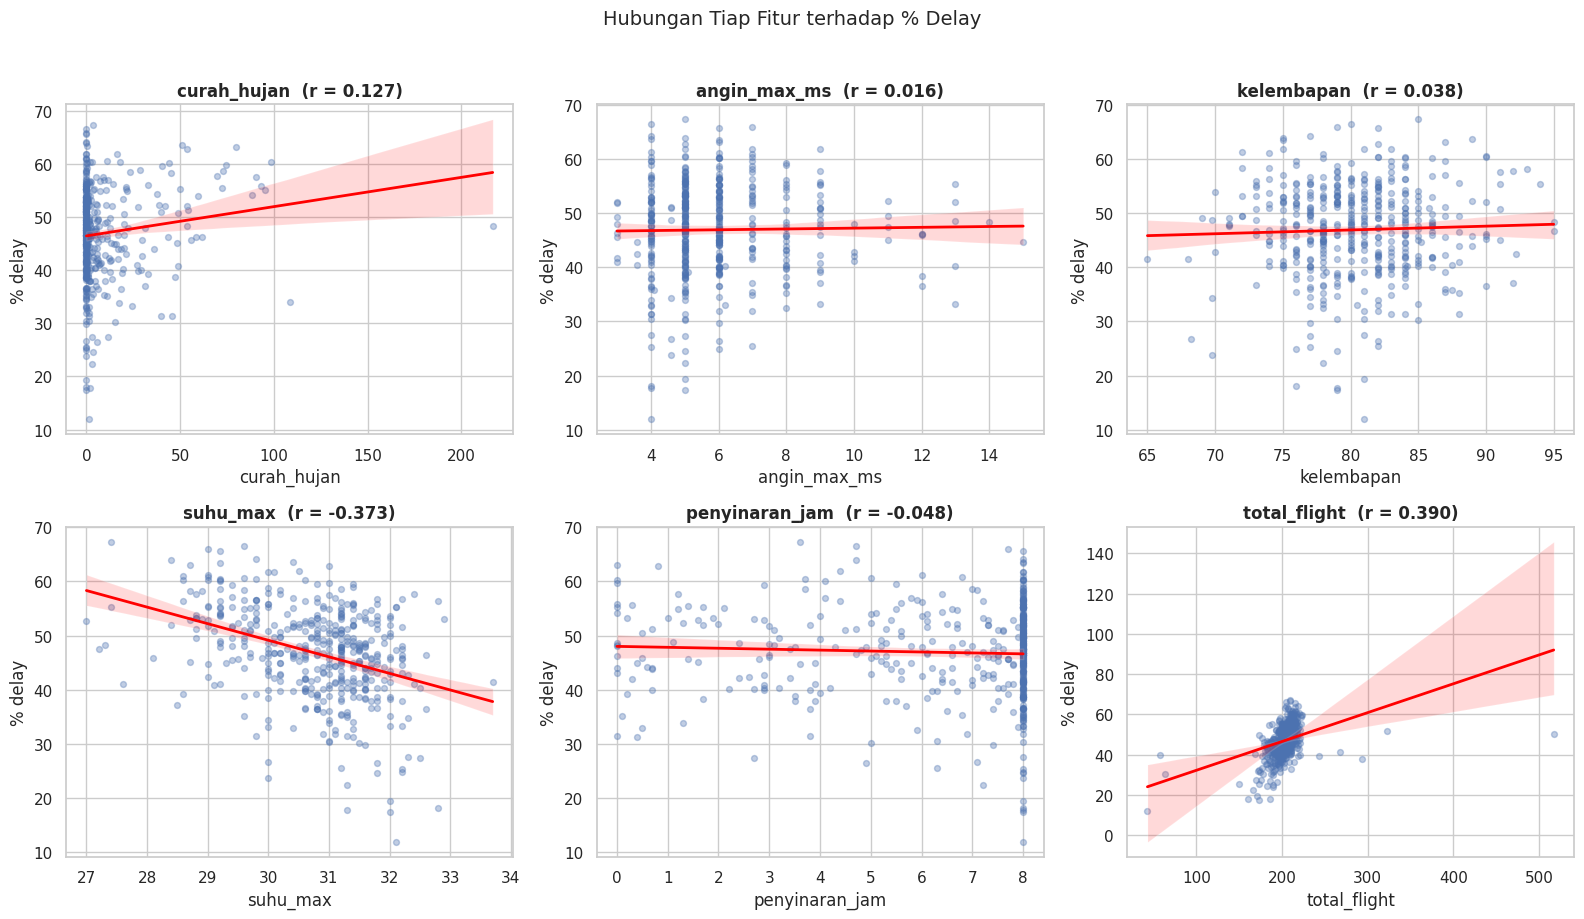

Pengamatan: titik tersebar luas (awan), garis tren landai -> hubungan lemah.
Sinyal terkuat terlihat pada total_flight (positif) & suhu_max (negatif).


In [ ]:
fitur_scatter = ["curah_hujan","angin_max_ms","kelembapan","suhu_max",
                 "penyinaran_jam","total_flight"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), fitur_scatter):
    sns.regplot(data=df, x=col, y="pct_delay", ax=ax, scatter_kws={"alpha":0.35,"s":18},
                line_kws={"color":"red","lw":2})
    r = df[col].corr(df["pct_delay"])
    ax.set_title(f"{col}  (r = {r:.3f})", fontweight="bold")
    ax.set_ylabel("% delay")
plt.suptitle("Hubungan Tiap Fitur terhadap % Delay", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Pengamatan: titik tersebar luas (awan), garis tren landai -> hubungan lemah.")
print("Sinyal terkuat terlihat pada total_flight (positif) & suhu_max (negatif).")

## 2.9 Analisis Deret Waktu Mendalam (Rolling Window)

Berbeda dari panel ringkas di bagian 8V, di sini tren `pct_delay` dianalisis berdiri sendiri dengan **beberapa ukuran rolling window** (7, 14, 30 hari) untuk memisahkan fluktuasi harian (*noise*) dari tren jangka menengah. Rolling *std* memperlihatkan periode mana yang paling bergejolak.

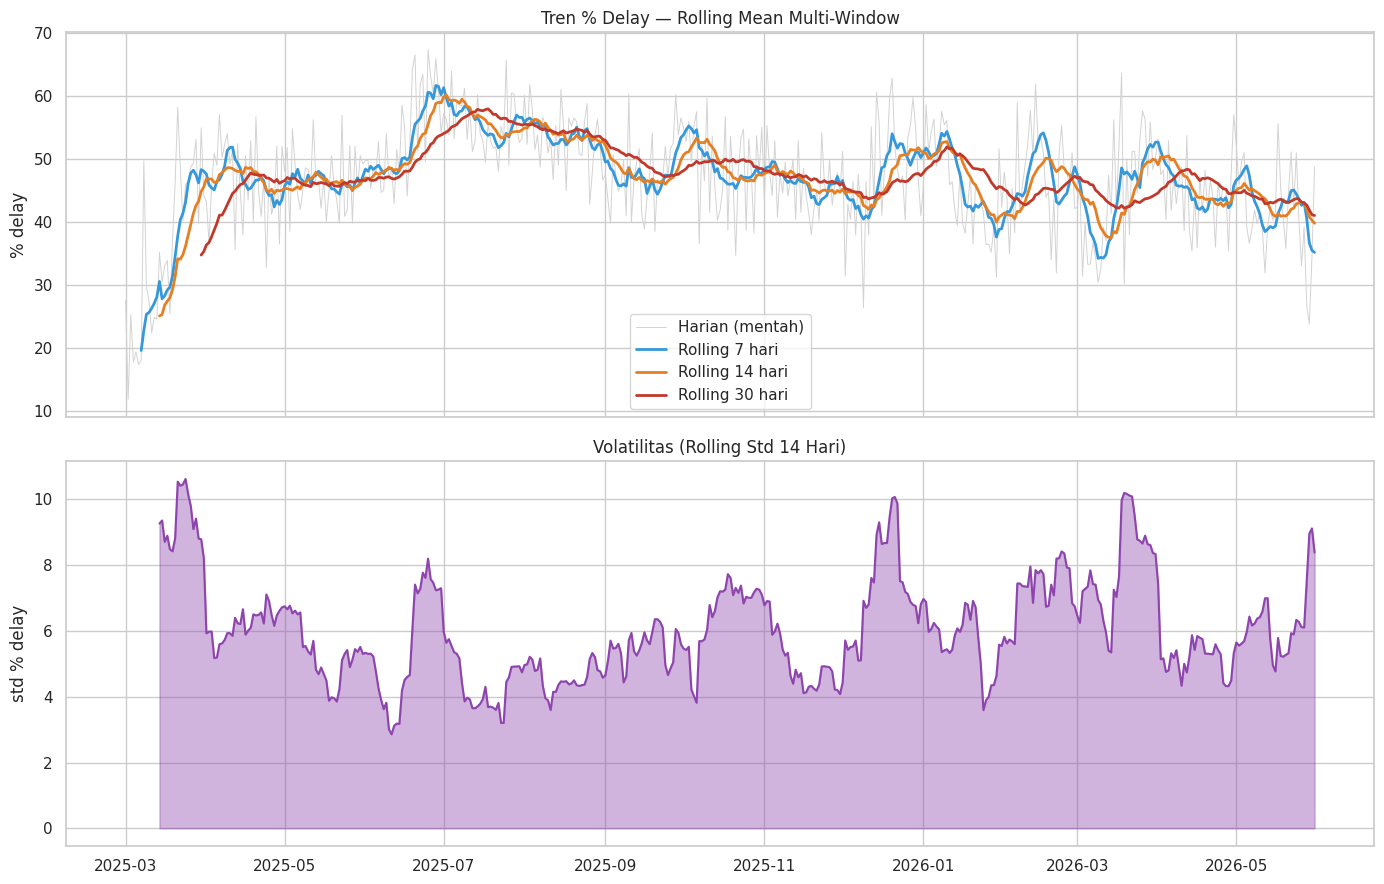

Periode paling fluktuatif (std tertinggi): sekitar 2025-03-24 (std=10.62)
Periode paling stabil (std terendah)     : sekitar 2025-06-11 (std=2.86)


In [ ]:
ts = df.set_index("tanggal")["pct_delay"]

fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# (atas) rolling mean berbagai window
ax[0].plot(ts.index, ts.values, color="lightgray", lw=0.7, label="Harian (mentah)")
for w, c in zip([7,14,30], ["#3498db","#e67e22","#c0392b"]):
    ax[0].plot(ts.index, ts.rolling(w).mean(), lw=2, color=c, label=f"Rolling {w} hari")
ax[0].set_title("Tren % Delay — Rolling Mean Multi-Window"); ax[0].set_ylabel("% delay"); ax[0].legend()

# (bawah) rolling std = volatilitas
ax[1].fill_between(ts.index, ts.rolling(14).std(), color="#8e44ad", alpha=0.4)
ax[1].plot(ts.index, ts.rolling(14).std(), color="#8e44ad", lw=1.5)
ax[1].set_title("Volatilitas (Rolling Std 14 Hari)"); ax[1].set_ylabel("std % delay")
plt.tight_layout(); plt.show()

# Periode paling bergejolak
vol = ts.rolling(14).std()
print(f"Periode paling fluktuatif (std tertinggi): sekitar {vol.idxmax().date()} (std={vol.max():.2f})")
print(f"Periode paling stabil (std terendah)     : sekitar {vol.idxmin().date()} (std={vol.min():.2f})")

## 2.10 Analisis Hari Ekstrem (Pembatalan & Beban Penerbangan)

Hari dengan **pembatalan terbanyak** atau **jumlah penerbangan tertinggi** adalah kasus menarik untuk diperiksa: apakah hari-hari ekstrem ini disertai cuaca buruk? Apakah delay-nya juga melonjak?

In [ ]:
print("=== 7 Hari dengan PEMBATALAN Terbanyak ===")
top_cancel = df.nlargest(7, "cancelled")[["tanggal","cancelled","total_flight",
              "pct_delay","curah_hujan","kategori_hujan","angin_max_ms"]]
print(top_cancel.to_string(index=False))

print("\n=== 7 Hari dengan PENERBANGAN Terbanyak ===")
top_flight = df.nlargest(7, "total_flight")[["tanggal","total_flight","cancelled",
              "pct_delay","curah_hujan","kategori_hujan"]]
print(top_flight.to_string(index=False))

# Perbandingan rata-rata: hari ekstrem cancel vs hari normal
amb_cancel = df["cancelled"].quantile(0.90)
ekstrem = df[df["cancelled"] >= amb_cancel]
normal  = df[df["cancelled"] <  amb_cancel]
print(f"\n=== Hari pembatalan tinggi (top 10%, cancelled>={amb_cancel:.0f}) vs normal ===")
banding = pd.DataFrame({
    "Pembatalan Tinggi": ekstrem[["pct_delay","curah_hujan","angin_max_ms","kelembapan"]].mean(),
    "Hari Normal"      : normal[["pct_delay","curah_hujan","angin_max_ms","kelembapan"]].mean(),
}).round(2)
print(banding)

=== 7 Hari dengan PEMBATALAN Terbanyak ===
   tanggal  cancelled  total_flight  pct_delay  curah_hujan kategori_hujan  angin_max_ms
2025-06-18         28           205       52.0          0.0    Tidak Hujan           5.0
2025-06-11         24           213       48.7          1.8  Sangat Ringan           6.0
2025-03-06         18           173       17.4          0.0    Tidak Hujan           5.0
2025-05-16         17           208       46.6          0.2  Sangat Ringan           6.0
2025-05-20         17           201       45.7          0.0    Tidak Hujan           6.0
2025-06-07         17           205       44.7          0.5  Sangat Ringan           6.0
2025-03-13         16           183       24.6          3.6  Sangat Ringan           5.0

=== 7 Hari dengan PENERBANGAN Terbanyak ===
   tanggal  total_flight  cancelled  pct_delay  curah_hujan kategori_hujan
2026-03-31           517          0       50.1          0.4  Sangat Ringan
2026-01-07           322          0       51.9    

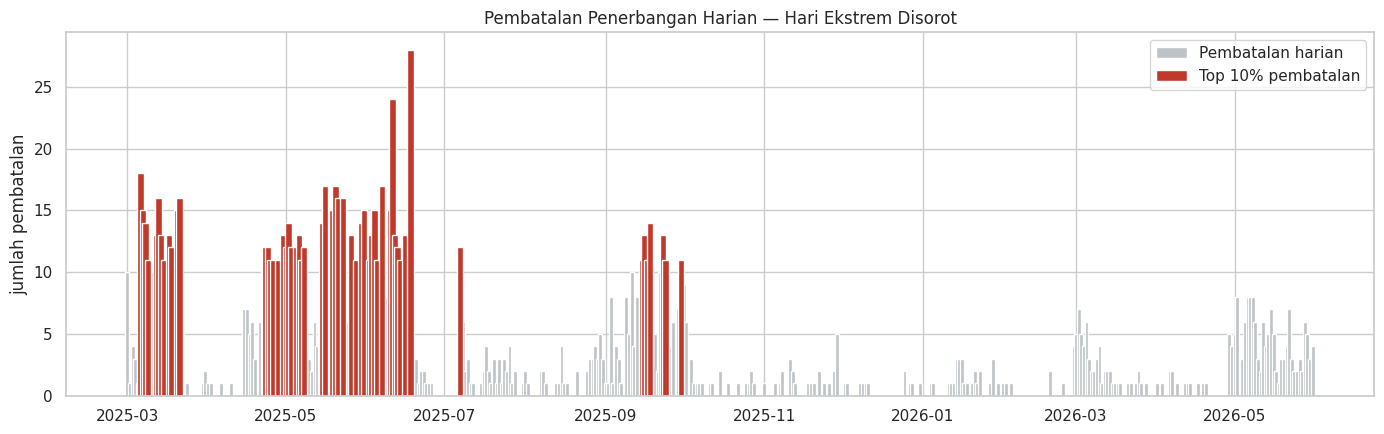

In [ ]:
# Visual: posisi hari ekstrem pada deret waktu
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(df["tanggal"], df["cancelled"], width=1.5, color="#bdc3c7", label="Pembatalan harian")
hot = df[df["cancelled"] >= amb_cancel]
ax.bar(hot["tanggal"], hot["cancelled"], width=2.5, color="#c0392b", label="Top 10% pembatalan")
ax.set_title("Pembatalan Penerbangan Harian — Hari Ekstrem Disorot")
ax.set_ylabel("jumlah pembatalan"); ax.legend()
plt.tight_layout(); plt.show()

# 3. Rekayasa Fitur & Pra-pemrosesan

Sebelum pemodelan, kita siapkan data:

1. **Bersihkan** anomali `arah_angin` (`E;SE` → `E`).
2. **Fitur temporal**: bulan, hari dalam minggu, akhir pekan.
3. **Definisi target** klasifikasi biner: **Hari Delay Tinggi** = `pct_delay` di atas median.
4. **Cegah kebocoran data (*leakage*)**: variabel turunan langsung dari delay (`pct_ontime`, `pct_delay`, `avg_delay_menit`, `delay`, `ontime`, `early`, `cancelled`, `operated`) **tidak** dipakai sebagai prediktor.

In [ ]:
data = df.copy()

# 1) Bersihkan arah angin
data["arah_angin"] = data["arah_angin"].str.split(";").str[0]

# 2) Fitur temporal
data["bulan_num"]  = data["tanggal"].dt.month
data["hari_minggu"]= data["tanggal"].dt.dayofweek          # 0=Senin
data["is_weekend"] = (data["hari_minggu"] >= 5).astype(int)

# 3) Target biner
ambang = data["pct_delay"].median()
data["delay_tinggi"] = (data["pct_delay"] > ambang).astype(int)
print(f"Ambang (median pct_delay) = {ambang:.2f}%")
print(data["delay_tinggi"].value_counts().rename({0:"Rendah (<=median)",1:"Tinggi (>median)"}))

# 4) Pilih prediktor — cuaca + beban operasional terjadwal + temporal (TANPA bocoran)
fitur_num = ["suhu_min","suhu_max","suhu_avg","kelembapan","curah_hujan",
             "penyinaran_jam","angin_max_ms","angin_avg_ms","total_flight",
             "bulan_num","hari_minggu","is_weekend"]
fitur_kat = ["kategori_hujan","arah_angin"]

X = pd.get_dummies(data[fitur_num + fitur_kat], columns=fitur_kat, drop_first=True)
y = data["delay_tinggi"]
print(f"\nDimensi matriks fitur X: {X.shape}")
X.head()

Ambang (median pct_delay) = 47.50%
delay_tinggi
Rendah (<=median)    229
Tinggi (>median)     228
Name: count, dtype: int64

Dimensi matriks fitur X: (457, 24)


,suhu_min,suhu_max,suhu_avg,kelembapan,curah_hujan,penyinaran_jam,angin_max_ms,angin_avg_ms,total_flight,bulan_num,...,kategori_hujan_Sangat Lebat,kategori_hujan_Sangat Ringan,kategori_hujan_Sedang,kategori_hujan_Tidak Hujan,arah_angin_NE,arah_angin_NW,arah_angin_S,arah_angin_SE,arah_angin_SW,arah_angin_W
0,25.2,32.3,28.0,81.0,11.4,8.0,4.0,2.0,170,3,...,False,False,False,False,False,False,False,False,False,False
1,25.3,32.1,28.7,81.0,1.2,8.0,4.0,2.0,43,3,...,False,True,False,False,False,False,False,False,False,False
2,25.8,32.2,28.6,77.0,0.0,8.0,4.0,2.0,150,3,...,False,False,False,True,False,False,False,False,False,False
3,25.8,31.3,28.5,79.0,1.7,8.0,4.0,2.0,160,3,...,False,True,False,False,False,False,False,False,False,False
4,26.0,32.0,28.8,81.0,0.0,8.0,5.0,3.0,171,3,...,False,False,False,True,False,False,False,False,False,False


# 4. Pemodelan

Kita bandingkan **tiga algoritma klasifikasi** dengan karakter berbeda:

- **Logistic Regression** — *baseline* linier, mudah diinterpretasi.
- **Random Forest** — *ensemble* pohon, menangkap interaksi non-linier.
- **Gradient Boosting** — *boosting* bertahap, sering paling akurat.

Data dibagi 80% latih / 20% uji dengan **stratifikasi** (menjaga proporsi kelas). Fitur numerik distandардisasi via `Pipeline` agar Logistic Regression adil.

> **Catatan:** karena ini data deret waktu, idealnya validasi memakai *time-based split*. Untuk tujuan pembelajaran kita pakai stratified split, namun *cross-validation* di bawah memberi estimasi yang lebih stabil.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Latih: {X_train.shape[0]} baris | Uji: {X_test.shape[0]} baris")

model = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000, random_state=42))]),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, max_depth=8,
                                                  random_state=42, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                      random_state=42),
}
for nama, m in model.items():
    m.fit(X_train, y_train)
print("\nSemua model selesai dilatih.")

Latih: 365 baris | Uji: 92 baris



Semua model selesai dilatih.


# 5. Evaluasi Model

Evaluasi memakai beberapa lensa agar tidak menyesatkan:

- **Accuracy** — proporsi prediksi benar (bisa menipu kalau kelas tak seimbang).
- **Precision / Recall / F1** — keseimbangan antara *false alarm* dan *miss*.
- **ROC-AUC** — kemampuan memisahkan kelas pada berbagai ambang.
- **Confusion Matrix** — rincian benar/salah per kelas.
- **Cross-Validation** — kestabilan performa lintas lipatan data.

## 5.1 Tabel Perbandingan Metrik

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

baris = []
for nama, m in model.items():
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    baris.append({
        "Model"    : nama,
        "Accuracy" : accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall"   : recall_score(y_test, pred),
        "F1-Score" : f1_score(y_test, pred),
        "ROC-AUC"  : roc_auc_score(y_test, proba),
    })
hasil = pd.DataFrame(baris).set_index("Model").round(4)
hasil.style.background_gradient(cmap="Greens", axis=0).format("{:.4f}")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6739,0.7353,0.5435,0.6250,0.7505
Random Forest,0.7391,0.7895,0.6522,0.7143,0.7902
Gradient Boosting,0.6304,0.6364,0.6087,0.6222,0.7339


## 5.2 Validasi Silang (5-Fold Stratified)

Mengukur kestabilan akurasi pada seluruh data, bukan satu pembagian saja.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Akurasi cross-validation (mean +/- std):")
for nama, m in model.items():
    skor = cross_val_score(m, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"  {nama:22s}: {skor.mean():.4f} +/- {skor.std():.4f}")

Akurasi cross-validation (mean +/- std):


  Logistic Regression   : 0.7113 +/- 0.0398


  Random Forest         : 0.7200 +/- 0.0214


  Gradient Boosting     : 0.7178 +/- 0.0373


## 5.3 Confusion Matrix Tiap Model

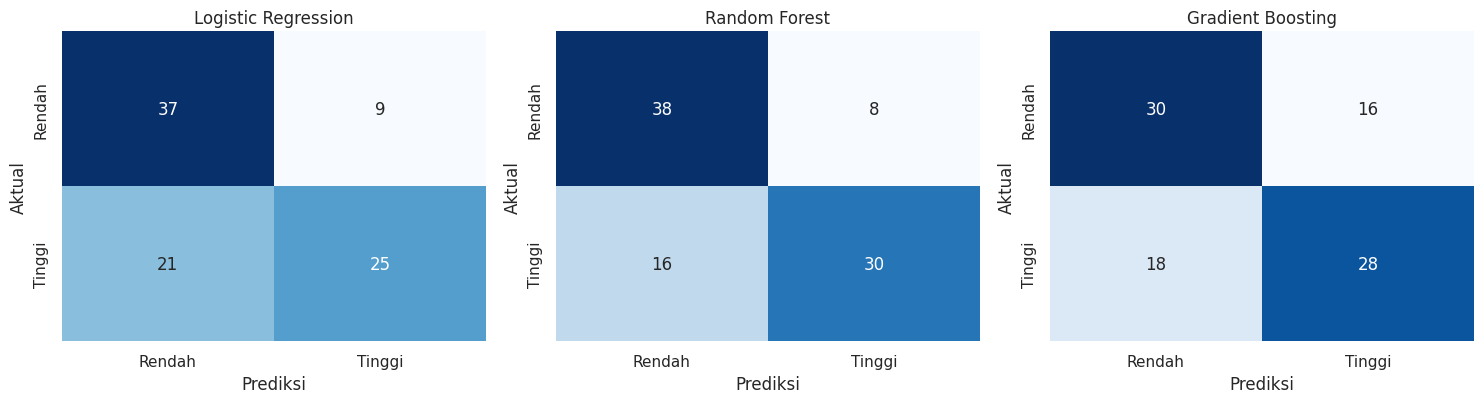

In [ ]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, (nama, m) in enumerate(model.items()):
    cm = confusion_matrix(y_test, m.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[i],
                xticklabels=["Rendah","Tinggi"], yticklabels=["Rendah","Tinggi"])
    ax[i].set_title(nama); ax[i].set_xlabel("Prediksi"); ax[i].set_ylabel("Aktual")
plt.tight_layout(); plt.show()

## 5.4 Kurva ROC

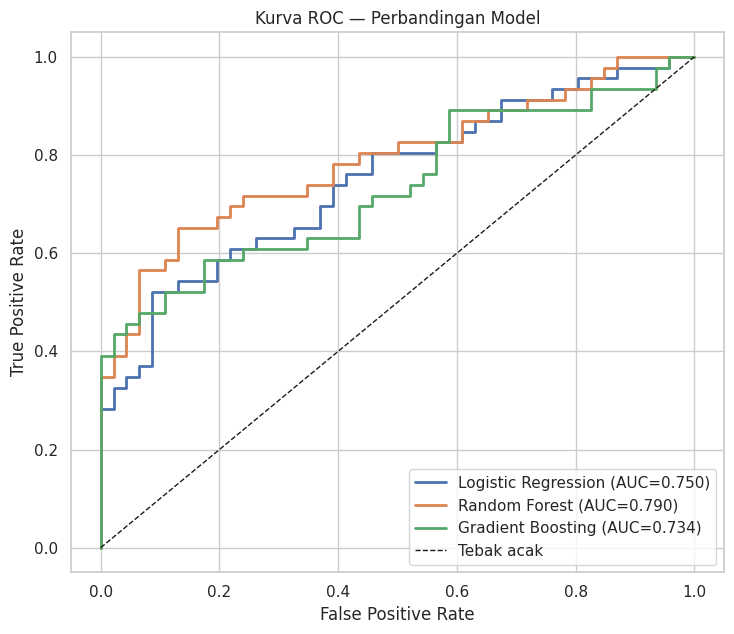

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7.5, 6.5))
for nama, m in model.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{nama} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1], "k--", lw=1, label="Tebak acak")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Kurva ROC — Perbandingan Model"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 5.5 Laporan Klasifikasi Model Terbaik

In [ ]:
from sklearn.metrics import classification_report

terbaik = hasil["F1-Score"].idxmax()
print(f">> Model terbaik berdasarkan F1-Score: {terbaik}\n")
pred = model[terbaik].predict(X_test)
print(classification_report(y_test, pred, target_names=["Delay Rendah","Delay Tinggi"]))

>> Model terbaik berdasarkan F1-Score: Random Forest

              precision    recall  f1-score   support

Delay Rendah       0.70      0.83      0.76        46
Delay Tinggi       0.79      0.65      0.71        46

    accuracy                           0.74        92
   macro avg       0.75      0.74      0.74        92
weighted avg       0.75      0.74      0.74        92



## 5.6 Pentingnya Fitur (*Feature Importance*)

Fitur apa yang paling menentukan prediksi? Diambil dari model berbasis pohon terbaik.

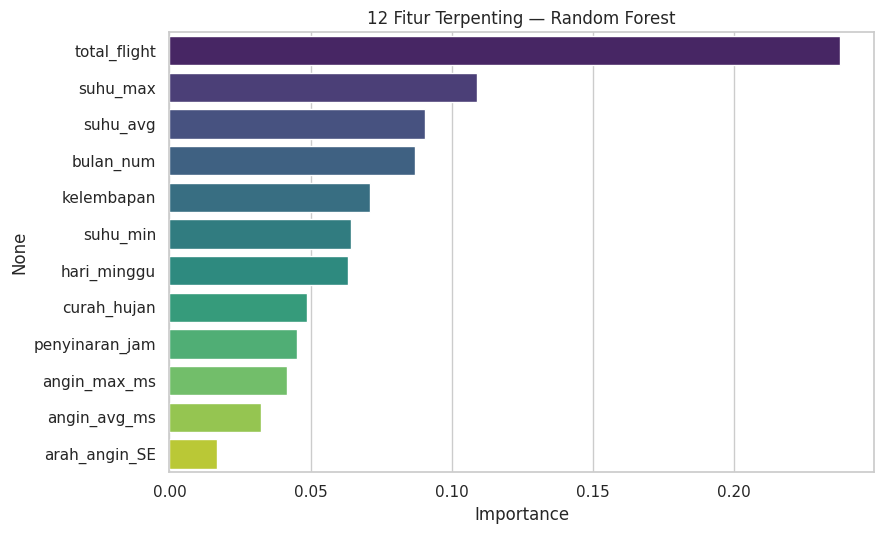

total_flight      0.2376
suhu_max          0.1090
suhu_avg          0.0905
bulan_num         0.0870
kelembapan        0.0711
suhu_min          0.0643
hari_minggu       0.0631
curah_hujan       0.0488
penyinaran_jam    0.0450
angin_max_ms      0.0415
angin_avg_ms      0.0323
arah_angin_SE     0.0168
dtype: float64


In [ ]:
tree_models = {k:v for k,v in model.items() if hasattr(v, "feature_importances_")}
pilih = terbaik if terbaik in tree_models else "Random Forest"
imp = pd.Series(model[pilih].feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(9,5.5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title(f"12 Fitur Terpenting — {pilih}"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
print(imp.round(4))

# 6. Kesimpulan

**Karakter data (8V).** Dataset ini bervolume kecil-menengah namun padat informasi (agregasi harian dari puluhan ribu penerbangan), berkecepatan *batch harian* yang kontinu, dan kaya ragam karena menggabungkan domain operasional penerbangan dengan meteorologi BMKG. Kualitasnya (*veracity*) tinggi — tanpa missing value, dengan dokumentasi imputasi yang transparan (`rr_imputed`) — dan lolos seluruh uji *validity* logis. Variabilitas tertinggi ada pada curah hujan yang sangat *skewed*.

**Temuan EDA.** Hubungan cuaca → keterlambatan ternyata **lebih lemah dari dugaan umum**. Curah hujan hanya berkorelasi ~0.13 dengan persentase delay; sinyal yang lebih konsisten justru datang dari **beban operasional** (`total_flight`) dan **suhu** (berkorelasi negatif, kemungkinan menjadi proksi musim/kondisi cuaca yang lebih luas).

**Performa model.** Ketiga model mampu memisahkan hari "delay tinggi" vs "rendah" di atas tebakan acak, dengan model *ensemble* (Random Forest / Gradient Boosting) unggul tipis atas baseline linier. *Feature importance* menegaskan dominasi fitur operasional dan temporal dibanding fitur cuaca murni.

**Implikasi & keterbatasan.**
- Cuaca **bukan** prediktor tunggal yang kuat untuk delay di DPS pada periode ini; faktor operasional & jadwal lebih menentukan.
- Keterbatasan: data hanya 1 bandara & ~15 bulan; validasi idealnya memakai *time-based split*; kategori hujan ekstrem terlalu langka untuk dipelajari model.
- Pengembangan lanjut: tambahkan fitur *lag* (kondisi H-1), data delay bandara asal, dan event hari libur nasional.

---
*Notebook ini disusun untuk tugas Big Data — analisis 8V, EDA, dan evaluasi model klasifikasi.*